# LightGCN Baseline Validation

This notebook:
1. Checks dataset stats for Amazon Video Games
2. Verifies setup by running Gowalla (known-good numbers)
3. Runs Video Games baseline
4. Runs layer sweep (1-4 layers) as control for adaptive layer experiment
5. Saves all results to JSON for team reference

In [1]:
import os
import sys
import json
import subprocess
import time
import re
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Adjust this to your repo root
REPO_ROOT = Path(".").resolve()
CODE_DIR = REPO_ROOT / "code"
DATA_DIR = REPO_ROOT / "data"
RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Code dir:  {CODE_DIR}")
print(f"Data dir:  {DATA_DIR}")
print(f"Datasets available: {[d.name for d in DATA_DIR.iterdir() if d.is_dir()]}")

Repo root: /var/home/alien/Nextcloud/GeorgiaTech/7643/project/LightGCN-PyTorch
Code dir:  /var/home/alien/Nextcloud/GeorgiaTech/7643/project/LightGCN-PyTorch/code
Data dir:  /var/home/alien/Nextcloud/GeorgiaTech/7643/project/LightGCN-PyTorch/data
Datasets available: ['amazon-book', 'gowalla', 'lastfm', 'yelp2018', 'amazon-videogames']


## 1. Dataset Stats

In [2]:
def load_dataset_stats(dataset_name):
    """Load train.txt and test.txt, compute basic stats."""
    dataset_dir = DATA_DIR / dataset_name
    
    train_users = defaultdict(list)
    test_users = defaultdict(list)
    
    with open(dataset_dir / "train.txt") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 1:
                uid = int(parts[0])
                items = [int(x) for x in parts[1:]]
                train_users[uid] = items
    
    with open(dataset_dir / "test.txt") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) > 1:
                uid = int(parts[0])
                items = [int(x) for x in parts[1:]]
                test_users[uid] = items
    
    all_items_train = set()
    all_items_test = set()
    for items in train_users.values():
        all_items_train.update(items)
    for items in test_users.values():
        all_items_test.update(items)
    
    n_users = max(max(train_users.keys(), default=0), max(test_users.keys(), default=0)) + 1
    n_items = max(max(all_items_train, default=0), max(all_items_test, default=0)) + 1
    n_train = sum(len(v) for v in train_users.values())
    n_test = sum(len(v) for v in test_users.values())
    sparsity = (n_train + n_test) / (n_users * n_items)
    
    train_counts = [len(v) for v in train_users.values()]
    
    return {
        "dataset": dataset_name,
        "n_users": n_users,
        "n_items": n_items,
        "n_train": n_train,
        "n_test": n_test,
        "n_total": n_train + n_test,
        "sparsity": sparsity,
        "train_counts": train_counts,
    }

In [3]:
# Load Video Games stats
vg_stats = load_dataset_stats("amazon-videogames")

print(f"{'='*50}")
print(f"Amazon Video Games Dataset Stats")
print(f"{'='*50}")
print(f"Users:        {vg_stats['n_users']:,}")
print(f"Items:        {vg_stats['n_items']:,}")
print(f"Train:        {vg_stats['n_train']:,}")
print(f"Test:         {vg_stats['n_test']:,}")
print(f"Total:        {vg_stats['n_total']:,}")
print(f"Sparsity:     {vg_stats['sparsity']:.6f}")
print(f"")
print(f"Avg items/user (train): {np.mean(vg_stats['train_counts']):.1f}")
print(f"Median items/user:      {np.median(vg_stats['train_counts']):.1f}")
print(f"Min items/user:         {np.min(vg_stats['train_counts'])}")
print(f"Max items/user:         {np.max(vg_stats['train_counts'])}")

# Viability check
if vg_stats['n_total'] < 10000:
    print("\n⚠️  WARNING: Very small dataset. Consider lowering K_CORE or switching category.")
elif vg_stats['n_total'] < 50000:
    print("\n⚠️  CAUTION: Small dataset. Results may be noisy. Consider K_CORE=3.")
else:
    print("\n✓ Dataset size looks reasonable for LightGCN experiments.")

Amazon Video Games Dataset Stats
Users:        94,762
Items:        25,612
Train:        675,879
Test:         138,707
Total:        814,586
Sparsity:     0.000336

Avg items/user (train): 7.1
Median items/user:      5.0
Min items/user:         4
Max items/user:         379

✓ Dataset size looks reasonable for LightGCN experiments.


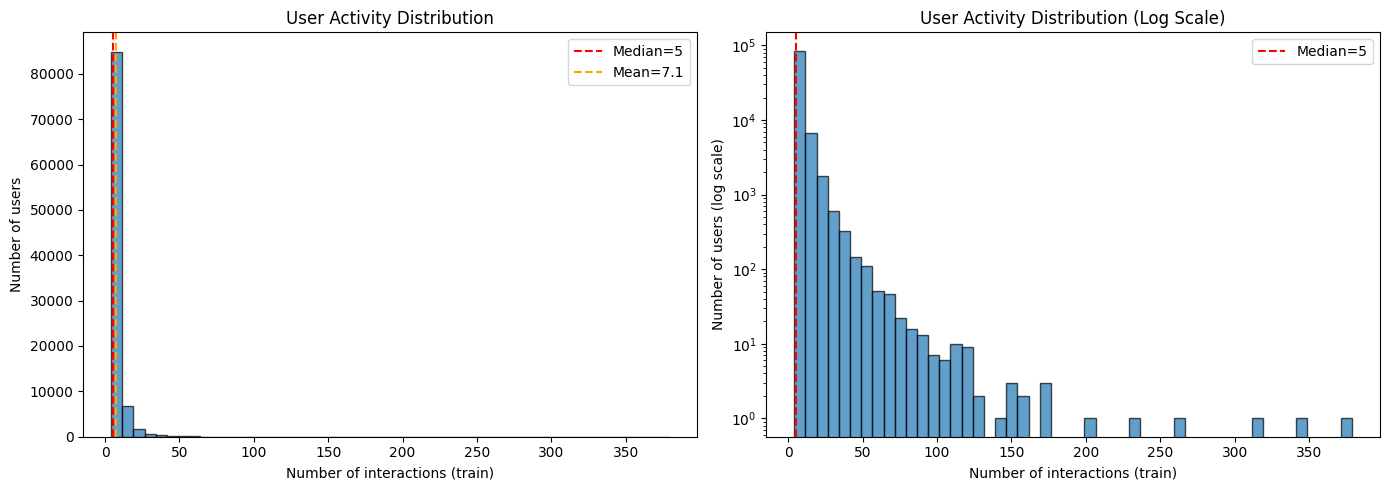

Saved to /var/home/alien/Nextcloud/GeorgiaTech/7643/project/LightGCN-PyTorch/results/user_activity_distribution.png


In [4]:
# Plot interaction distribution (shows the sparsity/long-tail your proposal talks about)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of items per user
counts = vg_stats['train_counts']
axes[0].hist(counts, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of interactions (train)')
axes[0].set_ylabel('Number of users')
axes[0].set_title('User Activity Distribution')
axes[0].axvline(np.median(counts), color='red', linestyle='--', label=f'Median={np.median(counts):.0f}')
axes[0].axvline(np.mean(counts), color='orange', linestyle='--', label=f'Mean={np.mean(counts):.1f}')
axes[0].legend()

# Log-scale version (shows long tail better)
axes[1].hist(counts, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of interactions (train)')
axes[1].set_ylabel('Number of users (log scale)')
axes[1].set_title('User Activity Distribution (Log Scale)')
axes[1].set_yscale('log')
axes[1].axvline(np.median(counts), color='red', linestyle='--', label=f'Median={np.median(counts):.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'user_activity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {RESULTS_DIR / 'user_activity_distribution.png'}")

## 2. Run Experiments

Helper function to run LightGCN and parse results from stdout.

In [5]:
def run_lightgcn(dataset, layers=3, lr=0.001, decay=1e-4, recdim=64,
                 epochs=1000, seed=2020, topks="[20]", batch_size=2048,
                 timeout_minutes=60):
    """
    Run LightGCN and parse final test metrics from stdout.
    Returns dict with recall, ndcg, precision, and training info.
    """
    cmd = [
        sys.executable, "main.py",
        f"--dataset={dataset}",
        f"--layer={layers}",
        f"--lr={lr}",
        f"--decay={decay}",
        f"--recdim={recdim}",
        f"--epochs={epochs}",
        f"--seed={seed}",
        f"--topks={topks}",
        f"--bpr_batch={batch_size}",
    ]
    
    print(f"Running: {' '.join(cmd)}")
    print(f"Working dir: {CODE_DIR}")
    start_time = time.time()
    
    try:
        result = subprocess.run(
            cmd,
            cwd=str(CODE_DIR),
            capture_output=True,
            text=True,
            timeout=timeout_minutes * 60
        )
    except subprocess.TimeoutExpired:
        print(f"TIMEOUT after {timeout_minutes} minutes")
        return None
    
    elapsed = time.time() - start_time
    output = result.stdout + result.stderr
    
    # Print last 20 lines of output for monitoring
    lines = output.strip().split('\n')
    print(f"\n--- Last 20 lines of output ---")
    for line in lines[-20:]:
        print(line)
    print(f"--- End output (total {len(lines)} lines, {elapsed:.0f}s) ---\n")
    
    # Parse best results
    # The repo prints lines like:
    # EPOCH[X/1000] ... {'precision': array([0.03]), 'recall': array([0.18]), 'ndcg': array([0.15])}
    # And at the end: Best Iter=[X] recall=[0.183], precision=[0.029], ndcg=[0.153]
    
    metrics = {
        "dataset": dataset,
        "layers": layers,
        "lr": lr,
        "decay": decay,
        "recdim": recdim,
        "seed": seed,
        "elapsed_seconds": round(elapsed, 1),
        "recall_20": None,
        "ndcg_20": None,
        "precision_20": None,
    }
    
    # Try to parse "Best Iter" line
    for line in reversed(lines):
        if "recall=" in line and "ndcg=" in line:
            recall_match = re.search(r'recall=\[([\d.]+)\]', line)
            ndcg_match = re.search(r'ndcg=\[([\d.]+)\]', line)
            prec_match = re.search(r'precision=\[([\d.]+)\]', line)
            
            if recall_match:
                metrics["recall_20"] = float(recall_match.group(1))
            if ndcg_match:
                metrics["ndcg_20"] = float(ndcg_match.group(1))
            if prec_match:
                metrics["precision_20"] = float(prec_match.group(1))
            break
    
    # Fallback: parse from dict-style output
    if metrics["recall_20"] is None:
        for line in reversed(lines):
            if "'recall'" in line and "array" in line:
                recall_match = re.search(r"'recall':\s*array\(\[([\d.]+)\]", line)
                ndcg_match = re.search(r"'ndcg':\s*array\(\[([\d.]+)\]", line)
                prec_match = re.search(r"'precision':\s*array\(\[([\d.]+)\]", line)
                if recall_match:
                    metrics["recall_20"] = float(recall_match.group(1))
                if ndcg_match:
                    metrics["ndcg_20"] = float(ndcg_match.group(1))
                if prec_match:
                    metrics["precision_20"] = float(prec_match.group(1))
                break
    
    if all(metrics[k] is not None for k in ["recall_20", "ndcg_20", "precision_20"]):
        print(f"✓ Results: Recall@20={metrics['recall_20']:.4f}, "
            f"NDCG@20={metrics['ndcg_20']:.4f}, "
            f"Precision@20={metrics['precision_20']:.4f}")
    else:
        print("⚠️  Could not fully parse metrics from output. Check logs above.")
        print("Parsed so far:",
            {k: metrics[k] for k in ["recall_20", "ndcg_20", "precision_20"]})
        metrics["raw_output_tail"] = "\n".join(lines[-30:])
    
    return metrics

### 2a. Verify on Gowalla (skip if already confirmed)

In [6]:
# Uncomment to run Gowalla verification
# Expected: Recall@20 ≈ 0.183, NDCG@20 ≈ 0.153

# gowalla_results = run_lightgcn("gowalla", layers=3, epochs=1000)
# print(f"\nGowalla verification:")
# print(f"  Expected Recall@20 ≈ 0.183, Got: {gowalla_results.get('recall_20')}")
# print(f"  Expected NDCG@20   ≈ 0.153, Got: {gowalla_results.get('ndcg_20')}")

### 2b. Video Games Baseline (3 layers, default hyperparams)

In [7]:
baseline = run_lightgcn(
    "amazon-videogames",
    layers=3,
    lr=0.001,
    decay=1e-4,
    recdim=64,
    epochs=1, #000,
    timeout_minutes=120
)

if baseline:
    with open(RESULTS_DIR / "baseline.json", "w") as f:
        json.dump(baseline, f, indent=2)
    print(f"\nSaved to {RESULTS_DIR / 'baseline.json'}")

Running: /var/home/alien/.local/share/mamba/envs/bts_fanclub/bin/python main.py --dataset=amazon-videogames --layer=3 --lr=0.001 --decay=0.0001 --recdim=64 --epochs=1 --seed=2020 --topks=[20] --bpr_batch=2048
Working dir: /var/home/alien/Nextcloud/GeorgiaTech/7643/project/LightGCN-PyTorch/code

--- Last 20 lines of output ---
 'multicore': 0,
 'pretrain': 0,
 'test_u_batch_size': 100}
cores for test: 6
comment: lgn
tensorboard: 1
LOAD: 0
Weight path: ./checkpoints
Test Topks: [20]
using bpr loss
===========end===================
use NORMAL distribution initilizer
loading adjacency matrix
successfully loaded...
don't split the matrix
lgn is already to go(dropout:0)
load and save to /var/home/alien/Nextcloud/GeorgiaTech/7643/project/LightGCN-PyTorch/code/checkpoints/lgn-amazon-videogames-3-64.pth.tar
[TEST]
{'precision': array([6.38441569e-05]), 'recall': array([0.0009326]), 'ndcg': array([0.00034766])}
EPOCH[1/1] loss0.605-|Sample:8.59|
--- End output (total 38 lines, 59s) ---

⚠️  Coul

### 2c. Layer Sweep (1, 2, 3, 4 layers)

This is the control group for adaptive layer experiment.
Shows how fixed equal-weight layer combination performs at each depth.

In [8]:
layer_results = []

for n_layers in [1, 2, 3, 4]:
    print(f"\n{'='*60}")
    print(f"Running {n_layers}-layer LightGCN on Amazon Video Games")
    print(f"{'='*60}")
    
    result = run_lightgcn(
        "amazon-videogames",
        layers=n_layers,
        lr=0.001,
        decay=1e-4,
        recdim=64,
        epochs=1000,
        timeout_minutes=120
    )
    
    if result:
        layer_results.append(result)

# Save all layer sweep results
with open(RESULTS_DIR / "layer_sweep.json", "w") as f:
    json.dump(layer_results, f, indent=2)
print(f"\nSaved to {RESULTS_DIR / 'layer_sweep.json'}")


Running 1-layer LightGCN on Amazon Video Games
Running: /var/home/alien/.local/share/mamba/envs/bts_fanclub/bin/python main.py --dataset=amazon-videogames --layer=1 --lr=0.001 --decay=0.0001 --recdim=64 --epochs=1000 --seed=2020 --topks=[20] --bpr_batch=2048
Working dir: /var/home/alien/Nextcloud/GeorgiaTech/7643/project/LightGCN-PyTorch/code


KeyboardInterrupt: 

## 3. Results Summary

In [ ]:
# Load results (in case you're restarting the notebook)
if not layer_results:
    with open(RESULTS_DIR / "layer_sweep.json") as f:
        layer_results = json.load(f)

# Print summary table
print(f"\n{'='*60}")
print(f"Layer Sweep Results: Amazon Video Games")
print(f"{'='*60}")
print(f"{'Layers':<8} {'Recall@20':<12} {'NDCG@20':<12} {'Precision@20':<14} {'Time (s)':<10}")
print(f"{'-'*56}")

for r in layer_results:
    recall = r.get('recall_20', 'N/A')
    ndcg = r.get('ndcg_20', 'N/A')
    prec = r.get('precision_20', 'N/A')
    elapsed = r.get('elapsed_seconds', 'N/A')
    
    recall_str = f"{recall:.4f}" if isinstance(recall, float) else recall
    ndcg_str = f"{ndcg:.4f}" if isinstance(ndcg, float) else ndcg
    prec_str = f"{prec:.4f}" if isinstance(prec, float) else prec
    
    print(f"{r['layers']:<8} {recall_str:<12} {ndcg_str:<12} {prec_str:<14} {elapsed}")


Layer Sweep Results: Amazon Video Games
Layers   Recall@20    NDCG@20      Precision@20   Time (s)  
--------------------------------------------------------


TypeError: unsupported format string passed to NoneType.__format__

In [ ]:
# Plot layer sweep
valid_results = [r for r in layer_results if r.get('recall_20') is not None]

if valid_results:
    layers = [r['layers'] for r in valid_results]
    recalls = [r['recall_20'] for r in valid_results]
    ndcgs = [r['ndcg_20'] for r in valid_results]

    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.plot(layers, recalls, 'o-', label='Recall@20', markersize=8, linewidth=2)
    ax.plot(layers, ndcgs, 's-', label='NDCG@20', markersize=8, linewidth=2)
    ax.set_xlabel('Number of LightGCN Layers', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('LightGCN Baseline: Layer Sweep on Amazon Video Games', fontsize=13)
    ax.set_xticks(layers)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'layer_sweep.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {RESULTS_DIR / 'layer_sweep.png'}")
else:
    print("No valid results to plot. Check experiment outputs above.")

## 4. Sparsity Analysis

Break users into quartiles by activity level. This supports the proposal's
sparsity narrative and will be the control for showing your improvements
help sparse users most.

In [ ]:
counts = np.array(vg_stats['train_counts'])

q25 = np.percentile(counts, 25)
q50 = np.percentile(counts, 50)
q75 = np.percentile(counts, 75)

sparse = np.sum(counts <= q25)
moderate = np.sum((counts > q25) & (counts <= q50))
active = np.sum((counts > q50) & (counts <= q75))
power = np.sum(counts > q75)

print(f"User Activity Quartiles (train interactions):")
print(f"  Q1 (sparse):   <= {q25:.0f} items  ({sparse:,} users, {sparse/len(counts)*100:.1f}%)")
print(f"  Q2 (moderate): {q25:.0f}-{q50:.0f} items  ({moderate:,} users, {moderate/len(counts)*100:.1f}%)")
print(f"  Q3 (active):   {q50:.0f}-{q75:.0f} items  ({active:,} users, {active/len(counts)*100:.1f}%)")
print(f"  Q4 (power):    > {q75:.0f} items  ({power:,} users, {power/len(counts)*100:.1f}%)")
print(f"\nThis long-tail distribution is what motivates the sparsity focus.")
print(f"Your experiments should show improvement is largest for Q1/Q2 users.")

## 5. Export Summary for Team

Save everything teammates need to compare their experiments against baseline.

In [ ]:
team_summary = {
    "dataset": {
        "name": "Amazon Reviews 2023 - Video Games",
        "source": "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023",
        "n_users": vg_stats["n_users"],
        "n_items": vg_stats["n_items"],
        "n_train": vg_stats["n_train"],
        "n_test": vg_stats["n_test"],
        "sparsity": vg_stats["sparsity"],
        "avg_items_per_user": float(np.mean(vg_stats["train_counts"])),
        "median_items_per_user": float(np.median(vg_stats["train_counts"])),
    },
    "baseline_config": {
        "model": "LightGCN (gusye1234/LightGCN-PyTorch)",
        "layers": 3,
        "embedding_dim": 64,
        "lr": 0.001,
        "decay": 1e-4,
        "loss": "BPR",
        "negative_sampling": "uniform random",
        "optimizer": "Adam",
        "seed": 2020,
    },
    "baseline_results": baseline if baseline else "not yet run",
    "layer_sweep": layer_results if layer_results else "not yet run",
}

with open(RESULTS_DIR / "team_summary.json", "w") as f:
    json.dump(team_summary, f, indent=2)

print(f"Team summary saved to {RESULTS_DIR / 'team_summary.json'}")
print(f"\nShare this file + layer_sweep.png + user_activity_distribution.png")
print(f"with your teammates so they have the baseline to compare against.")